In [13]:
%%bash
set -e
mkdir -p outputs tmp_ndl
echo "ready."

ready.


In [ ]:
%%bash
set -euo pipefail

cat > ndl_union_by_id.R << 'RS'
suppressWarnings({ library(httr); library(xml2); library(readr); library(dplyr); library(stringi) })
dir.create("outputs", showWarnings = FALSE)

# ===== 変更可 =====
START_YEAR <- 1911
THIS_YEAR  <- as.integer(format(Sys.Date(), "%Y"))
YEARS      <- START_YEAR:THIS_YEAR

OS_URL    <- "https://ndlsearch.ndl.go.jp/api/opensearch"
PER_PAGE  <- 100     # NDL OpenSearchは100ページまで
PAGES_MAX <- 80      # ページ数
PAUSE     <- 0.25    # スピード

# キーワード（補充可）
NIHONBASHI <- c("日本橋","日本桥","にほんばし","ニホンバシ","Nihonbashi")
NIHONBASHI_RIVER  <- c("日本橋川","日本桥川", "にほんばしがわ", "ニホンバシガワ", "Nihonbashi-gawa", "舟運", "魚河岸", "河岸", "Water transport", "船着場", "発着場", "canal","waterway", "Nihonbashi gawa",
             "waterfront","quay","Nihonbashi River","Nihonbashi river side","river cruise","boat")
ELEVEDS <- c("首都高","首都高速","高架","高速道路", "首都高日本橋", "高速", "高架橋", "都心環状線", "環状線", "日本橋区間", "Inner Circular Route", "metropolitan expressway", "Shuto Expressway","Shutoko","expressway","elevated","viaduct","overpass","under expressway")

ua <- user_agent("NDL-UnionByID/1.0 (+https://ndlsearch.ndl.go.jp/)")

# 二重カウント排除
fetch_ids_one <- function(q, y, idx){
  res <- GET(OS_URL, query=list(any=q,
                                from=sprintf("%d-01-01", y),
                                until=sprintf("%d-12-31", y),
                                cnt=PER_PAGE, idx=idx), ua)
  if (http_error(res)) return(character())
  doc <- tryCatch(read_xml(content(res, "raw")), error=function(e) NULL)
  if (is.null(doc)) return(character())
  items <- xml_find_all(doc, "//*[local-name()='item']")
  if (length(items)==0) return(character())
  ids <- character()
  for (it in items){
    link <- xml_text(xml_find_first(it, "./*[local-name()='link']"))
    if (is.na(link) || link==""){
      link <- xml_text(xml_find_first(it, "./*[local-name()='guid']"))
    }
    if (!is.na(link) && nzchar(link)) ids <- c(ids, link)
  }
  unique(ids)
}

# カウントされた数を集計
fetch_ids_query_year <- function(q, y){
  all <- character()
  for (p in 1:PAGES_MAX){
    idx <- (p-1)*PER_PAGE + 1
    ids <- fetch_ids_one(q, y, idx)
    if (length(ids)==0) break
    all <- unique(c(all, ids))
    if (length(ids) < PER_PAGE) break
    Sys.sleep(PAUSE)
  }
  all
}

# 分母： NIHONBASHI
collect_bridge_year <- function(y){
  all <- character()
  for (b in NIHONBASHI){
    ids <- fetch_ids_query_year(b, y)
    all <- unique(c(all, ids))
  }
  all
}

# 分子A：NIHONBSHI×NIHONBASHI RIVER
collect_A_year <- function(y){
  all <- character()
  for (b in NIHONBASHI) for (r in NIHONBASHI_RIVER){
    ids <- fetch_ids_query_year(paste(b, r), y)
    all <- unique(c(all, ids))
  }
  all
}

# 分子B：NIHONBASHI×ELEVEDS
collect_B_year <- function(y){
  all <- character()
  for (b in NIHONBASHI) for (e in ELEVEDS){
    ids <- fetch_ids_query_year(paste(b, e), y)
    all <- unique(c(all, ids))
  }
  all
}

rows <- list()
for (y in YEARS){
  cat("Year", y, "...\n")
  setBridge <- collect_bridge_year(y)
  setA      <- collect_A_year(y)
  setB      <- collect_B_year(y)
  rows[[length(rows)+1]] <- data.frame(
    year=y,
    denom_bridge=length(setBridge),
    num_A=length(setA),
    num_B=length(setB)
  )
}

out <- bind_rows(rows) %>% arrange(year)
write_csv(out, "outputs/ndl_popular_yearly.csv")
cat("Wrote outputs/ndl_popular_yearly.csv\n")
print(tail(out, 8))
RS

Rscript ndl_union_by_id.R
echo "---- head outputs/ndl_popular_yearly.csv ----"
(head -n 10 outputs/ndl_popular_yearly.csv || true)

### 1. 必要なライブラリのインポートとデータの生成

まず、データ生成とモデルトレーニングに必要なライブラリをインポートし、シンプルな線形回帰モデルのトレーニングに適した合成データセットを作成します。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# シードを設定して再現性を確保
np.random.seed(0)

# データの生成
X = np.random.rand(100, 1) * 10  # 0から10までのランダムなX値
y = 2 * X + 1 + np.random.randn(100, 1) * 2  # y = 2X + 1 にノイズを追加

print("生成されたデータの形状:")
print(f"Xの形状: {X.shape}")
print(f"yの形状: {y.shape}")

生成されたデータの形状:
Xの形状: (100, 1)
yの形状: (100, 1)


### 2. データをトレーニングセットとテストセットに分割

モデルが未知のデータに対してどの程度うまく機能するかを評価するために、データセットをトレーニングセットとテストセットに分割します。

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("データ分割後の形状:")
print(f"X_trainの形状: {X_train.shape}")
print(f"y_trainの形状: {y_train.shape}")
print(f"X_testの形状: {X_test.shape}")
print(f"y_testの形状: {y_test.shape}")

データ分割後の形状:
X_trainの形状: (80, 1)
y_trainの形状: (80, 1)
X_testの形状: (20, 1)
y_testの形状: (20, 1)


### 3. 線形回帰モデルのトレーニング

`LinearRegression`モデルのインスタンスを作成し、トレーニングデータ(`X_train`, `y_train`)を使用してトレーニングします。

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"モデルの係数 (傾き): {model.coef_[0][0]:.2f}")
print(f"モデルの切片: {model.intercept_[0]:.2f}")

モデルの係数 (傾き): 2.00
モデルの切片: 1.41


### 4. テストデータでの予測とモデルの評価

トレーニングされたモデルを使用してテストデータで予測を行い、平均二乗誤差 (Mean Squared Error, MSE) を計算してモデルの性能を評価します。

In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"平均二乗誤差 (MSE): {mse:.2f}")

平均二乗誤差 (MSE): 3.67


### 5. 結果の可視化

元のデータ、トレーニングデータ、およびモデルによって生成された回帰直線をプロットして、モデルがデータにどのようにフィットしているかを視覚的に確認します。

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24112 (\N{CJK UNIFIED IDEOGRAPH-5E30}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

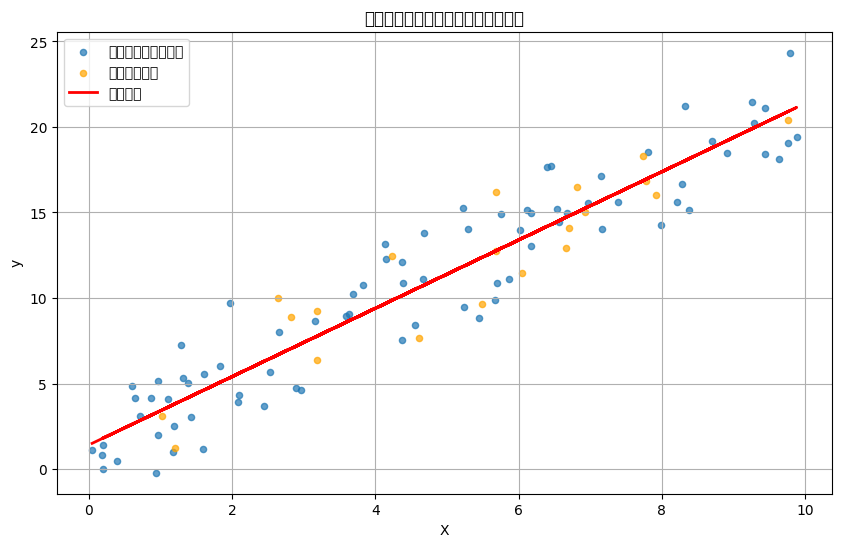

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, s=20, label='トレーニングデータ', alpha=0.7)
plt.scatter(X_test, y_test, s=20, label='テストデータ', alpha=0.7, color='orange')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='回帰直線')
plt.xlabel('X')
plt.ylabel('y')
plt.title('線形回帰モデルのトレーニング結果')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#check every year
%%bash
Rscript - <<'RS'
suppressWarnings({ library(readr) })
d <- read_csv("outputs/ndl_popular_yearly.csv", show_col_types=FALSE)

for (i in seq_len(nrow(d))) {
  cat(sprintf("%3d %4d %6d %4d %4d\n",
              i, d$year[i], d$denom_bridge[i], d$num_A[i], d$num_B[i]))
}
RS

In [ ]:
#文献check1
%%bash
set -e
YEAR=2010
Q='%22%E6%97%A5%E6%9C%AC%E6%A9%8B%22'  # "日本橋"
echo "[OpenSearch] $YEAR 日本橋 (head 120 lines of RSS)"
curl -s --compressed -H "Accept: application/rss+xml" -A "Sampler/1.0" \
  "https://ndlsearch.ndl.go.jp/api/opensearch?any=${Q}&from=${YEAR}-01-01&until=${YEAR}-12-31&cnt=1&idx=1" \
  | sed -n '1,120p'

In [ ]:
%%bash
set -euo pipefail

Rscript - <<'RS'
suppressWarnings({ library(readr); library(dplyr); library(tidyr) }) # Add tidyr here
dir.create("outputs", showWarnings = FALSE)

# 統計結果を読み込み
ndl <- read_csv("outputs/ndl_popular_yearly.csv", show_col_types = FALSE) %>% arrange(year)

# 1911年から現在までの完全な年次系列を用意し，欠測年の件数を 0 で補完した。各年の割合（分子÷分母）を算出する（分母が 0 の年は NA とする）。
START_YEAR <- 1911
THIS_YEAR  <- as.integer(format(Sys.Date(), "%Y"))
years      <- tibble(year = START_YEAR:THIS_YEAR)
# 移動平均：10年
ma <- function(x,k=10){ stats::filter(x, rep(1/k,k), sides=2) }

dat <- years %>%
  left_join(ndl, by="year") %>%
  mutate(across(c(denom_bridge, num_A, num_B), ~replace_na(., 0))) %>% # NA　→ 0、数値0　→　整数0
  mutate(
    prop_A      = ifelse(denom_bridge>0, num_A/denom_bridge, NA_real_),   # 日本橋&日本橋川/日本橋関連記述 比率
    prop_B      = ifelse(denom_bridge>0, num_B/denom_bridge, NA_real_),   # 日本橋&高架/日本橋関連記述 比率
    prop_A_ma3  = as.numeric(ma(prop_A, 10)),                              # 移動平均：10年
    prop_B_ma3  = as.numeric(ma(prop_B, 10))
  )

write_csv(dat, "outputs/ndl_only_timeseries.csv")
cat("✓ Wrote outputs/ndl_only_timeseries.csv\n")
print(tail(dat, 10))
RS

In [ ]:
#Noto CJK フォント（日本語対応） を入れて有効化する
%%bash
set -e
apt-get -qq update
apt-get -qq install -y fonts-noto-cjk
fc-cache -f
fc-list | grep -E "Noto.*(CJK|JP)" | head

In [ ]:
#0~1
%%bash
set -euo pipefail
# CJK（中日韓）フォントをインストールする
apt-get -qq update
apt-get -qq install -y fonts-noto-cjk
fc-cache -f

# Install R packages
Rscript -e 'install.packages(c("showtext", "sysfonts"), repos="http://cran.rstudio.com")'


Rscript - <<'RS'
suppressWarnings({
  library(readr); library(showtext); library(sysfonts)
})

# CJK フォントファイルを直接登録する
font_file <- "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
picked <- "" # Default to empty

if (file.exists(font_file)) {
  sysfonts::font_add(family="CJK", regular=font_file)
  picked <- "CJK"
  message("Registered font from file: ", font_file)
  showtext_auto()
} else {
  message("Warning: NotoSansCJK-Regular.ttc not found at expected path. Using default system font.")
}


# データを読み込み、チャート生成
dat <- read_csv("outputs/ndl_only_timeseries.csv", show_col_types=FALSE)

main_title <- "「川」から「高架」へ：日本橋における景観イメージの転換（1911–2025）"
x_lab      <- "年"
y_lab      <- "共起率（日本橋関連記録に占める割合）"
legend_lab <- c("日本橋 & 日本橋川（A）", "日本橋 & 高架（B）")

png("outputs/ndl_only_1911_present.png", width=1200, height=720, type="cairo")
# 選択したフォントファミリーを使用し、なければデフォルトとして空文字列（""）にフォールバックする。
par(mar=c(5,6,4,1.5), family=picked)

yr <- dat$year
plot(yr, dat$prop_A_ma3, type="l", lwd=2, ylim=c(0,1),
     xlab=x_lab, ylab=y_lab, main=main_title)
lines(yr, dat$prop_B_ma3, lwd=2, lty=2)
#　縦破線
abline(v=1963, lty=3); abline(v=1958, lty=3); abline(v=1923, lty=3); abline(v=1911, lty=3); abline(v=1950, lty=3); abline(v=2002, lty=3)

# Add text labels
text(1963, 0.2, "←高架の竣工\n(1963)", pos=4, cex=0.9)     # y=垂直位置
text(1958, 0.24, "←高架建設決定\n(1958)", pos=4, cex=0.9)
text(1950, 0.3, "←モータリゼーション\nが急速に進展(1950~)", pos=4, cex=0.9)
text(1911, 0.24, "←石造橋に架け替え\n(1911)", pos=4, cex=0.9)
text(2002, 0.2, "←日本橋地区における\n首都高の再構築案を提示(2002)", pos=4, cex=0.9)
text(1923, 0.2, "←関東大震災\n(1923)", pos=4, cex=0.9)
legend("topright", legend=legend_lab, lty=c(1,2), lwd=2, bty="n")

dev.off()
cat("✓ 图已保存：outputs/ndl_only_1911_present.png，使用字体：", picked, "\n")
RS

In [ ]:
#～0.2ver.
%%bash
set -euo pipefail
# CJK（中日韓）フォントをインストールする
apt-get -qq update
apt-get -qq install -y fonts-noto-cjk
fc-cache -f

# Install R packages
Rscript -e 'install.packages(c("showtext", "sysfonts"), repos="http://cran.rstudio.com")'

Rscript - <<'RS'
suppressWarnings({
  library(readr); library(showtext); library(sysfonts)
})

# CJK フォントファイルを直接登録する
font_file <- "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
picked <- "" # Default to empty

if (file.exists(font_file)) {
  sysfonts::font_add(family="CJK", regular=font_file)
  picked <- "CJK"
  message("Registered font from file: ", font_file)
  showtext_auto()
} else {
  message("Warning: NotoSansCJK-Regular.ttc not found at expected path. Using default system font.")
}

# データを読み込み、チャート生成
dat <- read_csv("outputs/ndl_only_timeseries.csv", show_col_types=FALSE)

main_title <- "「川」から「高架」へ：日本橋における景観イメージの転換（1911–2025）"
x_lab      <- "年"
y_lab      <- "共起率（日本橋関連記録に占める割合）"
legend_lab <- c("日本橋 & 日本橋川（A）", "日本橋 & 高架（B）")

png("outputs/ndl_only_1911_present.png", width=1200, height=720, type="cairo")
par(mar=c(5,6,4,1.5), family=picked)

yr <- dat$year
plot(yr, dat$prop_A_ma3, type="l", lwd=2, ylim=c(0,0.2),  #  0〜1 → 0〜0.2
     xlab=x_lab, ylab=y_lab, main=main_title)
lines(yr, dat$prop_B_ma3, lwd=2, lty=2)

# 縦破線
abline(v=c(1911,1923,1950,1958,1963,2002,1937,1945), lty=3)

text(1963, 0.07, "←高架の竣工(1963)", pos=4, cex=0.9)
text(1958, 0.09,"←高架建設決定(1958)", pos=4, cex=0.9)
text(1950, 0.11,"←モータリゼーション\nが急速に進展(1950~)", pos=4, cex=0.9)
text(1911, 0.07,"←石造橋に架け替え\n(1911)", pos=4, cex=0.9)
text(2002, 0.11, "←日本橋地区における\n首都高の再構築案を提示(2002)", pos=4, cex=0.9)
text(1923, 0.05, "←関東大震災\n(1923)", pos=4, cex=0.9)
text(1937, 0.07, "←日中戦争開始\n出版統制が加速\n(1937)", pos=4, cex=0.9)
text(1945, 0.05, "←終戦、出版統制が解除\n(1945)", pos=4, cex=0.9)

legend("topright", legend=legend_lab, lty=c(1,2), lwd=2, bty="n")
dev.off()
cat("✓ 图已保存：outputs/ndl_only_1911_present.png，使用字体：", picked, "\n")
RS
